# Posture Detection V2 — 02 Temporal 2D Keypoints and MotionBERT Mapping

This notebook extracts consecutive MediaPipe landmarks from every raw posture video, converts the 33-landmark representation into MotionBERT's 17-joint Human3.6M convention, preserves confidence and timestamps, audits missing detections, and exports fixed-length temporal windows.

MotionBERT's official implementation accepts H36M-format 17-joint sequences with lengths up to 243 frames. The mapping used here is explicit and approximate because MediaPipe and the detectors used in MotionBERT do not share identical landmark definitions. It must be reported and visually validated.

Official implementation: https://github.com/Walter0807/MotionBERT

## 1. Environment

In [1]:
# Uncomment in a fresh environment, then restart the kernel:
# %pip install -q mediapipe opencv-python pandas numpy matplotlib seaborn tqdm

import json
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')
print('OpenCV:', cv2.__version__)
print('MediaPipe:', mp.__version__)

OpenCV: 5.0.0
MediaPipe: 1.0.1


c:\Users\manth\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Locate the V2 project and inputs

In [2]:
working_directory = Path.cwd()
if working_directory.name == 'notebooks':
    PROJECT_ROOT = working_directory.parent
elif working_directory.name == 'project_v2':
    PROJECT_ROOT = working_directory
else:
    PROJECT_ROOT = working_directory / 'project_v2'

RAW_VIDEO_DIR = PROJECT_ROOT / 'data' / 'raw_videos'
ANNOTATION_DIR = PROJECT_ROOT / 'data' / 'annotations'
KEYPOINT_DIR = PROJECT_ROOT / 'data' / 'keypoints_2d'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'temporal_keypoints'
KEYPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

VIDEO_EXTENSIONS = {'.mp4', '.mov', '.avi', '.mkv', '.webm'}
video_paths = sorted(path for path in RAW_VIDEO_DIR.rglob('*') if path.suffix.lower() in VIDEO_EXTENSIONS)
video_stems = [path.stem for path in video_paths]
if len(video_stems) != len(set(video_stems)):
    raise ValueError('Raw videos contain duplicate filename stems; rename them before extraction.')
print('Project root:', PROJECT_ROOT.resolve())
print('Raw videos found:', len(video_paths))
if not video_paths:
    print('Add at least one genuine posture video to data/raw_videos, then rerun this notebook.')

Project root: C:\Users\manth\Desktop\project_v2
Raw videos found: 1


In [3]:
def read_optional_csv(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

participants = read_optional_csv(ANNOTATION_DIR / 'participants.csv')
sessions = read_optional_csv(ANNOTATION_DIR / 'sessions.csv')
clips = read_optional_csv(ANNOTATION_DIR / 'clips.csv')
print('Participants:', len(participants), '| Session rows:', len(sessions), '| Clip intervals:', len(clips))

Participants: 0 | Session rows: 0 | Clip intervals: 0


## 3. Configure extraction and temporal windows

In [4]:
WINDOW_LENGTH = 81       # 2.7 seconds at 30 FPS; MotionBERT supports up to 243
WINDOW_STRIDE = 27       # 0.9 seconds at 30 FPS
MAX_INTERPOLATION_GAP = 15
MIN_WINDOW_DETECTION_RATE = 0.80
MIN_MEAN_CONFIDENCE = 0.20
OVERWRITE_EXISTING = False

assert 1 <= WINDOW_LENGTH <= 243
assert 1 <= WINDOW_STRIDE <= WINDOW_LENGTH
print('Window length:', WINDOW_LENGTH, '| stride:', WINDOW_STRIDE)

Window length: 81 | stride: 27


## 4. Download and configure MediaPipe Pose Landmarker

In [5]:
MODEL_PATH = PROJECT_ROOT / 'models' / 'pose_landmarker_full.task'
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
MODEL_URL = (
    'https://storage.googleapis.com/mediapipe-models/pose_landmarker/'
    'pose_landmarker_full/float16/latest/pose_landmarker_full.task'
)
if not MODEL_PATH.exists():
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
RunningMode = mp.tasks.vision.RunningMode
video_options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(MODEL_PATH)),
    running_mode=RunningMode.VIDEO, num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_segmentation_masks=False,
)
print('Pose model:', MODEL_PATH.resolve())

Pose model: C:\Users\manth\Desktop\project_v2\models\pose_landmarker_full.task


## 5. Define the 33-to-17 mapping

MotionBERT joint order used here:

`pelvis, right_hip, right_knee, right_ankle, left_hip, left_knee, left_ankle, spine, thorax, nose/neck, head, left_shoulder, left_elbow, left_wrist, right_shoulder, right_elbow, right_wrist`

Pelvis, thorax, spine, and head-center joints are synthesized from MediaPipe landmarks. All synthesized confidences are conservative averages of their source landmarks.

In [6]:
MP = {
    'nose': 0, 'left_ear': 7, 'right_ear': 8,
    'left_shoulder': 11, 'right_shoulder': 12,
    'left_elbow': 13, 'right_elbow': 14,
    'left_wrist': 15, 'right_wrist': 16,
    'left_hip': 23, 'right_hip': 24,
    'left_knee': 25, 'right_knee': 26,
    'left_ankle': 27, 'right_ankle': 28,
}
H36M_NAMES = [
    'pelvis', 'right_hip', 'right_knee', 'right_ankle',
    'left_hip', 'left_knee', 'left_ankle', 'spine', 'thorax',
    'nose_neck', 'head', 'left_shoulder', 'left_elbow', 'left_wrist',
    'right_shoulder', 'right_elbow', 'right_wrist',
]
H36M_INDEX = {name: index for index, name in enumerate(H36M_NAMES)}

def average_joint(first, second):
    return np.nanmean(np.stack([first, second]), axis=0)

def mediapipe33_to_h36m17(frame33):
    # frame33 shape: (33, 5) = x, y, z, visibility, presence
    if frame33.shape != (33, 5):
        raise ValueError(f'Expected (33, 5), received {frame33.shape}')
    source = np.column_stack([frame33[:, 0], frame33[:, 1],
                              np.minimum(frame33[:, 3], frame33[:, 4])])
    output = np.full((17, 3), np.nan, dtype=np.float32)
    pelvis = average_joint(source[MP['left_hip']], source[MP['right_hip']])
    thorax = average_joint(source[MP['left_shoulder']], source[MP['right_shoulder']])
    head = average_joint(source[MP['left_ear']], source[MP['right_ear']])
    output[0] = pelvis
    output[1] = source[MP['right_hip']]
    output[2] = source[MP['right_knee']]
    output[3] = source[MP['right_ankle']]
    output[4] = source[MP['left_hip']]
    output[5] = source[MP['left_knee']]
    output[6] = source[MP['left_ankle']]
    output[7] = average_joint(pelvis, thorax)
    output[8] = thorax
    output[9] = source[MP['nose']]
    output[10] = head
    output[11] = source[MP['left_shoulder']]
    output[12] = source[MP['left_elbow']]
    output[13] = source[MP['left_wrist']]
    output[14] = source[MP['right_shoulder']]
    output[15] = source[MP['right_elbow']]
    output[16] = source[MP['right_wrist']]
    return output

def normalize_screen_coordinates(sequence17, width, height):
    normalized = sequence17.copy().astype(np.float32)
    normalized[..., 0] = normalized[..., 0] * 2.0 - 1.0
    normalized[..., 1] = (normalized[..., 1] * 2.0 - 1.0) * (height / width)
    return normalized

In [7]:
# Mapping unit test independent of real videos.
synthetic = np.zeros((33, 5), dtype=np.float32)
synthetic[:, 0] = 0.5
synthetic[:, 1] = np.linspace(0.1, 0.9, 33)
synthetic[:, 3:] = 1.0
mapped = mediapipe33_to_h36m17(synthetic)
assert mapped.shape == (17, 3)
assert np.isfinite(mapped).all()
assert np.allclose(mapped[0, :2], (synthetic[23, :2] + synthetic[24, :2]) / 2)
print('33-to-17 mapping unit test passed.')

33-to-17 mapping unit test passed.


## 6. Extract a complete temporal sequence from one video

In [8]:
def extract_video_sequence(video_path, landmarker):
    capture = cv2.VideoCapture(str(video_path))
    if not capture.isOpened():
        raise RuntimeError(f'Could not open {video_path}')
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    if fps <= 0:
        capture.release()
        raise ValueError(f'Invalid FPS for {video_path.name}: {fps}')

    frames33, frames17, timestamps, detected = [], [], [], []
    frame_index = 0
    last_timestamp_ms = -1
    try:
        while True:
            success, bgr = capture.read()
            if not success:
                break
            timestamp_ms = max(int(round(frame_index * 1000.0 / fps)), last_timestamp_ms + 1)
            last_timestamp_ms = timestamp_ms
            rgb = np.ascontiguousarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
            result = landmarker.detect_for_video(
                mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb), timestamp_ms
            )
            if result.pose_landmarks:
                landmarks = result.pose_landmarks[0]
                frame33 = np.array([
                    [item.x, item.y, item.z, item.visibility, item.presence]
                    for item in landmarks
                ], dtype=np.float32)
                frame17 = mediapipe33_to_h36m17(frame33)
                detected.append(True)
            else:
                frame33 = np.full((33, 5), np.nan, dtype=np.float32)
                frame17 = np.full((17, 3), np.nan, dtype=np.float32)
                detected.append(False)
            frames33.append(frame33)
            frames17.append(frame17)
            timestamps.append(timestamp_ms / 1000.0)
            frame_index += 1
    finally:
        capture.release()

    sequence33 = np.stack(frames33) if frames33 else np.empty((0, 33, 5), dtype=np.float32)
    sequence17_image = np.stack(frames17) if frames17 else np.empty((0, 17, 3), dtype=np.float32)
    sequence17_normalized = normalize_screen_coordinates(sequence17_image, width, height)
    return {
        'mediapipe_33_raw': sequence33,
        'h36m_17_raw': sequence17_normalized,
        'h36m_17_image_coordinates': sequence17_image,
        'timestamps_seconds': np.asarray(timestamps, dtype=np.float32),
        'detected_mask': np.asarray(detected, dtype=bool),
        'fps': fps, 'width': width, 'height': height,
    }

## 7. Interpolate short gaps without hiding detection failures
Only short missing stretches are interpolated. The raw arrays and detection mask remain saved, and windows containing unresolved missing values are rejected.

In [9]:
def interpolate_short_gaps(sequence, limit=MAX_INTERPOLATION_GAP):
    output = sequence.copy()
    frames = output.shape[0]
    flattened = output.reshape(frames, -1)
    interpolated = pd.DataFrame(flattened).interpolate(
        method='linear', axis=0, limit=limit, limit_direction='both',
    )
    return interpolated.to_numpy(dtype=np.float32).reshape(output.shape)

test_gap = np.ones((20, 17, 3), dtype=np.float32)
test_gap[5:8] = np.nan
assert np.isfinite(interpolate_short_gaps(test_gap, limit=5)).all()
print('Short-gap interpolation unit test passed.')

Short-gap interpolation unit test passed.


## 8. Process every raw video

In [10]:
sequence_records = []
with PoseLandmarker.create_from_options(video_options) as landmarker:
    for video_path in tqdm(video_paths, desc='Extracting temporal poses'):
        output_path = KEYPOINT_DIR / f'{video_path.stem}_keypoints.npz'
        if output_path.exists() and not OVERWRITE_EXISTING:
            with np.load(output_path) as existing:
                frame_count = len(existing['timestamps_seconds'])
                detected_count = int(existing['detected_mask'].sum())
                fps = float(existing['fps'])
                width = int(existing['width'])
                height = int(existing['height'])
            status = 'reused'
        else:
            sequence = extract_video_sequence(video_path, landmarker)
            interpolated17 = interpolate_short_gaps(sequence['h36m_17_raw'])
            np.savez_compressed(
                output_path,
                mediapipe_33_raw=sequence['mediapipe_33_raw'],
                h36m_17_raw=sequence['h36m_17_raw'],
                h36m_17_interpolated=interpolated17,
                h36m_17_image_coordinates=sequence['h36m_17_image_coordinates'],
                timestamps_seconds=sequence['timestamps_seconds'],
                detected_mask=sequence['detected_mask'],
                fps=np.float32(sequence['fps']), width=np.int32(sequence['width']),
                height=np.int32(sequence['height']), joint_names=np.asarray(H36M_NAMES),
            )
            frame_count = len(sequence['timestamps_seconds'])
            detected_count = int(sequence['detected_mask'].sum())
            fps, width, height = sequence['fps'], sequence['width'], sequence['height']
            status = 'processed'
        sequence_records.append({
            'video_filename': video_path.name, 'keypoint_file': output_path.relative_to(PROJECT_ROOT).as_posix(),
            'frames': frame_count, 'detected_frames': detected_count,
            'detection_rate': detected_count / frame_count if frame_count else 0.0,
            'fps': fps, 'width': width, 'height': height, 'status': status,
        })

sequence_audit = pd.DataFrame(sequence_records)
sequence_audit.to_csv(RESULTS_DIR / 'sequence_extraction_audit.csv', index=False)
display(sequence_audit)

Extracting temporal poses: 100%|██████████| 1/1 [00:23<00:00, 23.48s/it]


,video_filename,keypoint_file,frames,detected_frames,detection_rate,fps,width,height,status
0,DEMO_PEXELS_9130469_side_view.mp4,data/keypoints_2d/DEMO_PEXELS_9130469_side_vie...,402,402,1.0,30.0,2160,3840,processed


## 9. Visualize and verify the mapping

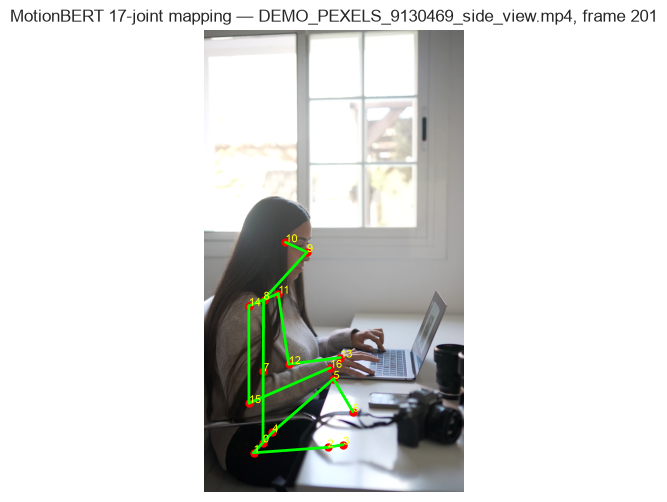

In [11]:
H36M_EDGES = [
    (0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6),
    (0, 7), (7, 8), (8, 9), (9, 10),
    (8, 11), (11, 12), (12, 13), (8, 14), (14, 15), (15, 16),
]

if video_paths and len(sequence_audit):
    preview_video = video_paths[0]
    keypoint_path = PROJECT_ROOT / sequence_audit.iloc[0]['keypoint_file']
    with np.load(keypoint_path) as sequence:
        detected_indices = np.flatnonzero(sequence['detected_mask'])
        frame_index = int(detected_indices[len(detected_indices) // 2]) if len(detected_indices) else 0
        joints = sequence['h36m_17_image_coordinates'][frame_index]
    capture = cv2.VideoCapture(str(preview_video))
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, bgr = capture.read()
    capture.release()
    if success:
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        height, width = rgb.shape[:2]
        plt.figure(figsize=(10, 6))
        plt.imshow(rgb)
        for first, second in H36M_EDGES:
            if np.isfinite(joints[[first, second], :2]).all():
                plt.plot(joints[[first, second], 0] * width, joints[[first, second], 1] * height, 'lime', linewidth=2)
        plt.scatter(joints[:, 0] * width, joints[:, 1] * height, c='red', s=25)
        for index, name in enumerate(H36M_NAMES):
            plt.text(joints[index, 0] * width, joints[index, 1] * height, str(index), color='yellow', fontsize=8)
        plt.title(f'MotionBERT 17-joint mapping — {preview_video.name}, frame {frame_index}')
        plt.axis('off')
        plt.show()
else:
    print('Mapping preview will appear after at least one video is processed.')

## 10. Create fixed-length temporal windows
A labeled training window must be fully contained inside one annotated interval. Unannotated windows are still exported for inference experiments but receive `label_status = unlabeled`.

In [12]:
LABEL_COLUMNS = [
    'good_posture', 'forward_head', 'slouching', 'lean_left', 'lean_right',
    'shoulder_imbalance', 'transition', 'uncertain',
]

def labels_for_window(video_filename, start_seconds, end_seconds):
    if clips.empty or 'video_filename' not in clips.columns:
        return {'label_status': 'unlabeled', **{name: -1 for name in LABEL_COLUMNS}}
    candidates = clips.loc[
        clips['video_filename'].eq(video_filename)
        & clips['start_seconds'].le(start_seconds)
        & clips['end_seconds'].ge(end_seconds)
    ]
    if len(candidates) != 1:
        return {'label_status': 'unlabeled', **{name: -1 for name in LABEL_COLUMNS}}
    row = candidates.iloc[0]
    return {'label_status': 'labeled', **{name: int(row.get(name, 0)) for name in LABEL_COLUMNS}}

window_arrays = []
window_rows = []
for record in sequence_records:
    keypoint_path = PROJECT_ROOT / record['keypoint_file']
    with np.load(keypoint_path) as sequence:
        poses = sequence['h36m_17_interpolated']
        raw_poses = sequence['h36m_17_raw']
        detected_mask = sequence['detected_mask']
        timestamps = sequence['timestamps_seconds']
    for start in range(0, max(0, len(poses) - WINDOW_LENGTH + 1), WINDOW_STRIDE):
        end = start + WINDOW_LENGTH
        window = poses[start:end]
        detection_rate = float(detected_mask[start:end].mean())
        mean_confidence = float(np.nanmean(raw_poses[start:end, :, 2]))
        finite = bool(np.isfinite(window).all())
        quality_pass = finite and detection_rate >= MIN_WINDOW_DETECTION_RATE and mean_confidence >= MIN_MEAN_CONFIDENCE
        start_seconds = float(timestamps[start])
        end_seconds = float(timestamps[end - 1])
        labels = labels_for_window(record['video_filename'], start_seconds, end_seconds)
        window_id = f"{Path(record['video_filename']).stem}_f{start:06d}_{end:06d}"
        window_rows.append({
            'window_id': window_id, 'video_filename': record['video_filename'],
            'start_frame': start, 'end_frame_exclusive': end,
            'start_seconds': start_seconds, 'end_seconds': end_seconds,
            'detection_rate': detection_rate, 'mean_confidence': mean_confidence,
            'finite_after_interpolation': finite, 'quality_pass': quality_pass, **labels,
        })
        window_arrays.append(window)

window_manifest = pd.DataFrame(window_rows)
if window_arrays:
    windows = np.stack(window_arrays).astype(np.float32)
else:
    windows = np.empty((0, WINDOW_LENGTH, 17, 3), dtype=np.float32)
np.savez_compressed(
    KEYPOINT_DIR / f'motionbert_windows_{WINDOW_LENGTH}.npz',
    windows=windows, window_ids=window_manifest.get('window_id', pd.Series(dtype=str)).to_numpy(),
    joint_names=np.asarray(H36M_NAMES),
)
window_manifest.to_csv(KEYPOINT_DIR / f'motionbert_windows_{WINDOW_LENGTH}_manifest.csv', index=False)
print('Window tensor:', windows.shape)
display(window_manifest.head())

Window tensor: (12, 81, 17, 3)


,window_id,video_filename,start_frame,end_frame_exclusive,start_seconds,end_seconds,detection_rate,mean_confidence,finite_after_interpolation,quality_pass,label_status,good_posture,forward_head,slouching,lean_left,lean_right,shoulder_imbalance,transition,uncertain
0,DEMO_PEXELS_9130469_side_view_f000000_000081,DEMO_PEXELS_9130469_side_view.mp4,0,81,0.0,2.667,1.0,0.713031,True,True,unlabeled,-1,-1,-1,-1,-1,-1,-1,-1
1,DEMO_PEXELS_9130469_side_view_f000027_000108,DEMO_PEXELS_9130469_side_view.mp4,27,108,0.9,3.567,1.0,0.701351,True,True,unlabeled,-1,-1,-1,-1,-1,-1,-1,-1
2,DEMO_PEXELS_9130469_side_view_f000054_000135,DEMO_PEXELS_9130469_side_view.mp4,54,135,1.8,4.467,1.0,0.705496,True,True,unlabeled,-1,-1,-1,-1,-1,-1,-1,-1
3,DEMO_PEXELS_9130469_side_view_f000081_000162,DEMO_PEXELS_9130469_side_view.mp4,81,162,2.7,5.367,1.0,0.704470,True,True,unlabeled,-1,-1,-1,-1,-1,-1,-1,-1
4,DEMO_PEXELS_9130469_side_view_f000108_000189,DEMO_PEXELS_9130469_side_view.mp4,108,189,3.6,6.267,1.0,0.693506,True,True,unlabeled,-1,-1,-1,-1,-1,-1,-1,-1


## 11. Quality and label coverage report

,video_filename,frames,detection_rate,fps,width,height
0,DEMO_PEXELS_9130469_side_view.mp4,402,1.0,30.0,2160,3840


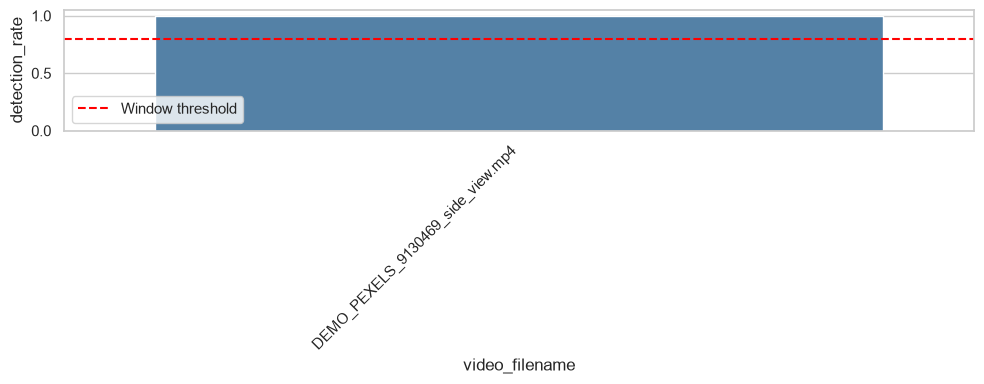

Windows: 12
Quality passes: 12
Labeled: 0


,positive_windows
good_posture,0
forward_head,0
slouching,0
lean_left,0
lean_right,0
shoulder_imbalance,0
transition,0
uncertain,0


In [13]:
if len(sequence_audit):
    display(sequence_audit[['video_filename', 'frames', 'detection_rate', 'fps', 'width', 'height']])
    plt.figure(figsize=(10, 4))
    sns.barplot(data=sequence_audit, x='video_filename', y='detection_rate', color='steelblue')
    plt.axhline(MIN_WINDOW_DETECTION_RATE, color='red', linestyle='--', label='Window threshold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()
if len(window_manifest):
    print('Windows:', len(window_manifest))
    print('Quality passes:', int(window_manifest['quality_pass'].sum()))
    print('Labeled:', int(window_manifest['label_status'].eq('labeled').sum()))
    coverage = {label: int(window_manifest[label].eq(1).sum()) for label in LABEL_COLUMNS}
    display(pd.Series(coverage, name='positive_windows').to_frame())
else:
    print('No windows yet. Record at least one video long enough for WINDOW_LENGTH frames.')

## 12. Save extraction metadata

In [14]:
metadata = {
    'source_format': 'MediaPipe Pose Landmarker, 33 landmarks',
    'target_format': 'MotionBERT Human3.6M, 17 joints',
    'joint_names': H36M_NAMES,
    'window_length': WINDOW_LENGTH, 'window_stride': WINDOW_STRIDE,
    'max_motionbert_length': 243,
    'max_interpolation_gap': MAX_INTERPOLATION_GAP,
    'minimum_window_detection_rate': MIN_WINDOW_DETECTION_RATE,
    'minimum_mean_confidence': MIN_MEAN_CONFIDENCE,
    'videos_processed': int(len(sequence_audit)),
    'windows_exported': int(len(window_manifest)),
    'quality_windows': int(window_manifest['quality_pass'].sum()) if len(window_manifest) else 0,
    'important_limitation': (
        'MediaPipe-to-H36M mapping is approximate and differs from the 2D detectors used to train MotionBERT.'
    ),
}
with (RESULTS_DIR / 'extraction_metadata.json').open('w') as file:
    json.dump(metadata, file, indent=2)
print('Saved outputs under:', KEYPOINT_DIR.resolve())
print('Saved audit under:', RESULTS_DIR.resolve())

Saved outputs under: C:\Users\manth\Desktop\project_v2\data\keypoints_2d
Saved audit under: C:\Users\manth\Desktop\project_v2\results\temporal_keypoints


## Completion criteria

Before moving to MotionBERT inference:

- At least one real video must be processed.
- The 17-joint overlay must align with the person's body.
- Detection failures and interpolation rates must be documented.
- Training windows must be fully contained within reviewed annotation intervals.
- Participant split assignments must remain independent.
- Low-quality windows must be excluded from training, not silently repaired.

### Next notebook
**V2 Notebook 03: MotionBERT 3D Pose Inference** will install the official implementation, load the pretrained 3D pose checkpoint, feed the accepted 17-joint temporal windows into DSTformer, export 3D joint sequences, visualize them, and benchmark inference latency.